In [129]:
import sys
from pathlib import Path

# Add repo root to sys.path
repo_root = Path.cwd().parent if Path.cwd().name == "sandbox" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

# Import from trace package
from trace.plotting.volcano import adjust_pvalues
from trace.statistics import compute_rd_pvalues


In [130]:
# Load and prepare data
data_path = "../data/semaglutide/plus50/combined_estimates.txt"
df_raw = pd.read_csv(data_path)

print(f"Loaded {len(df_raw)} rows")
print(f"Methods: {df_raw['method'].unique()}")
print(f"Unique outcomes: {df_raw['outcome'].nunique()}")
print(f"Runs: {df_raw['run_id'].nunique()}")


Loaded 13120 rows
Methods: ['IPW' 'TMLE' 'RD' 'RR']
Unique outcomes: 328
Runs: 10


In [131]:
# Filter to IPW method and pool across runs
method = "IPW"
df_method = df_raw[df_raw["method"] == method].copy()

print(f"\nFiltered to {method}: {len(df_method)} rows")

# Pool across runs
df_pooled = compute_rd_pvalues(
    df_method,
    group_cols=("method", "outcome"),
    arm_pooling="inter_intra_variance",
    verbose=False,
)

print(f"Pooled to {len(df_pooled)} unique outcomes")

# Calculate log RR
with np.errstate(divide="ignore", invalid="ignore"):
    df_pooled["RR"] = df_pooled["p1_hat"] / df_pooled["p0_hat"]
    df_pooled["log_RR"] = np.log(df_pooled["RR"])

# Adjust p-values
df_pooled["q_value"] = adjust_pvalues(df_pooled["p_value"].values, method="bh")

print(f"Significant outcomes (q<0.05): {(df_pooled['q_value'] < 0.05).sum()}")



Filtered to IPW: 3280 rows
  Output p_value: #nan=10, #inf=0, finite=318/328
Pooled to 328 unique outcomes
Significant outcomes (q<0.05): 237


In [132]:
# Prepare plotting dataframe
df_plot = df_pooled[["method", "outcome", "log_RR", "q_value", "p0_hat", "p1_hat"]].copy()

# Replace inf with nan
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)

# Drop rows with non-finite log_RR
n_before = len(df_plot)
df_plot = df_plot.dropna(subset=["log_RR"]).copy()
print(f"Dropped {n_before - len(df_plot)} rows with non-finite log_RR")

# Add min prevalence for easy filtering (handle NaN gracefully)
df_plot["min_prevalence"] = df_plot[["p0_hat", "p1_hat"]].min(axis=1)

# Add ATC group (first letter)
df_plot["group"] = df_plot["outcome"].astype(str).str[0]

# Sort by outcome
df_plot = df_plot.sort_values("outcome").reset_index(drop=True)

print(f"\nReady to plot {len(df_plot)} outcomes")
print(f"Groups: {', '.join(f'{g}({n})' for g, n in df_plot['group'].value_counts().sort_index().items())}")

# Report prevalence stats (excluding NaN)
p0_valid = df_plot['p0_hat'].dropna()
p1_valid = df_plot['p1_hat'].dropna()
min_prev_valid = df_plot['min_prevalence'].dropna()
if len(p0_valid) > 0 and len(p1_valid) > 0:
    print(f"Prevalence range: p0 [{p0_valid.min():.4f}, {p0_valid.max():.4f}], p1 [{p1_valid.min():.4f}, {p1_valid.max():.4f}]")
    print(f"Min prevalence range: [{min_prev_valid.min():.4f}, {min_prev_valid.max():.4f}]")


Dropped 8 rows with non-finite log_RR

Ready to plot 320 outcomes
Groups: A(52), B(23), C(33), D(16), G(13), H(8), J(31), L(25), M(14), N(50), P(7), R(21), S(20), V(7)
Prevalence range: p0 [0.0004, 0.3858], p1 [0.0003, 0.8544]
Min prevalence range: [0.0003, 0.3858]


In [133]:
def plot_circle_experimental(
    df: pd.DataFrame,
    *,
    outcome_col: str = "outcome",
    log_rr_col: str = "log_RR",
    q_value_col: str = "q_value",
    group_col: str = "group",
    figsize: Tuple[float, float] = (9, 12.6),
    sig_thresholds: Tuple[float, float, float] = (0.05, 0.01, 0.001),
    reds: Tuple[str, str, str] = ("#ffb3b3", "#bf3a3a", "#9c0202"),
    blues: Tuple[str, str, str] = ("#b3c6ff", "#4d79ff", "#0033cc"),
    neutral_color: str = "lightgrey",
    group_label_fontsize: int = 12,
    group_label_fontweight: str = "bold",
    group_label_radius: float = -1.8,
    radial_limit: float = None,
    max_bar_radius: float = None,
    show_separator_circle: bool = False,
    separator_circle_margin: float = 0.05,
    separator_circle_color: str = "gray",
    separator_circle_linewidth: float = 1.5,
    separator_circle_linestyle: str = "-",
) -> plt.Figure:
    """Create a circular (polar) plot with experimental features."""
    
    # Validate input
    required_cols = {outcome_col, log_rr_col, q_value_col, group_col}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"Missing columns: {', '.join(sorted(missing_cols))}")
    
    if df.empty:
        raise ValueError("Cannot create circle plot from empty dataframe")
    
    # Ensure sorted by outcome
    df = df.sort_values(outcome_col).reset_index(drop=True)
    
    # Extract data
    log_rr_values = df[log_rr_col].to_numpy()
    q_values = df[q_value_col].to_numpy()
    groups = df[group_col].unique()
    
    # Create angular positions
    n_outcomes = len(df)
    theta = np.linspace(0, 2 * np.pi, n_outcomes, endpoint=False)
    width = (2 * np.pi / n_outcomes) * 0.9
    
    # Bin q-values into significance levels
    bins = np.digitize(q_values, sig_thresholds)
    
    # Assign colors based on significance and direction
    colors_list = []
    reds_array = np.array(reds, dtype=object)
    blues_array = np.array(blues, dtype=object)
    
    for log_rr, q, b in zip(log_rr_values, q_values, bins):
        if np.isnan(q) or q >= sig_thresholds[0]:
            colors_list.append(neutral_color)
        else:
            idx = min(b - 1, len(reds) - 1)
            if log_rr > 0:
                colors_list.append(reds_array[idx])
            else:
                colors_list.append(blues_array[idx])
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={"projection": "polar"})
    
    # Scale bars if max_bar_radius is specified
    if max_bar_radius is not None:
        # Scale so longest bar reaches max_bar_radius
        max_original_length = np.max(np.abs(log_rr_values))
        target_length = 1 - max_bar_radius  # How long the longest bar should be
        scale_factor = target_length / max_original_length
        bar_heights = -np.abs(log_rr_values) * scale_factor
        actual_max_bar_length = target_length
    else:
        # Use original values
        bar_heights = -np.abs(log_rr_values)
        actual_max_bar_length = np.max(np.abs(log_rr_values))
    
    # Plot bars
    ax.bar(
        theta,
        bar_heights,
        bottom=1,
        width=width,
        color=colors_list,
    )
    
    # Calculate separator circle radius based on actual (possibly scaled) bar length
    circle_radius = 1 - actual_max_bar_length - separator_circle_margin
    
    # Set radial limits
    if radial_limit is None:
        # Use fixed generous limit that accommodates labels at various positions
        # This keeps bar scale consistent when you move labels
        ax.set_ylim(-3, 1)
    else:
        ax.set_ylim(radial_limit, 1)
    
    # Draw separator circle
    if show_separator_circle:
        circle_theta = np.linspace(0, 2*np.pi, 200)
        circle_r = np.full(200, circle_radius)
        ax.plot(
            circle_theta, 
            circle_r,
            color=separator_circle_color,
            linewidth=separator_circle_linewidth,
            linestyle=separator_circle_linestyle,
            clip_on=False,
            zorder=10,
        )
    
    # Add group labels
    for group in groups:
        group_mask = df[group_col] == group
        group_indices = df[group_mask].index.tolist()
        if not group_indices:
            continue
        
        idx = int(np.mean(group_indices))
        mid_theta = theta[idx]
        
        ax.text(
            mid_theta,
            group_label_radius,
            str(group),
            ha="center",
            va="center",
            rotation_mode="anchor",
            fontsize=group_label_fontsize,
            fontweight=group_label_fontweight,
            clip_on=False,
        )
    
    # Add separator lines between groups
    group_counts = df.groupby(group_col, sort=False).size()
    cumsum_indices = group_counts.cumsum().tolist()
    
    for idx in cumsum_indices[:-1]:
        separator_theta = theta[idx - 1] + width / 2
        ax.axvline(
            separator_theta,
            color="gray",
            lw=0.5,
            ls="--",
            clip_on=False,
            ymax=1,
        )
    
    # Add wrap-around separator
    if df[group_col].iloc[0] != df[group_col].iloc[-1]:
        wraparound_theta = theta[-1] + width / 2
        ax.axvline(
            wraparound_theta,
            color="gray",
            lw=0.5,
            ls="--",
            clip_on=False,
            ymax=1,
        )
    
    # Remove grid and angular labels
    ax.set_rgrids([])
    ax.set_thetagrids([])
    ax.grid(False)
    
    # Create legend
    _add_legend_inset(fig, reds, blues, neutral_color)
    
    return fig


def _add_legend_inset(
    fig: plt.Figure,
    reds: Tuple[str, str, str],
    blues: Tuple[str, str, str],
    neutral_color: str,
) -> None:
    """Add a custom legend inset showing significance levels."""
    legend_ax = fig.add_axes([0.4, -0.05, 0.5, 0.2])
    legend_ax.axis("off")
    
    labels = ["None", "Low", "Medium", "High"]
    reds_with_neutral = [neutral_color] + list(reds)
    blues_with_neutral = [neutral_color] + list(blues)
    
    # Row headers
    legend_ax.text(0, 0.9, "Positive", ha="right", va="center", fontweight="bold")
    legend_ax.text(0, 0.71, "Significance", ha="right", va="bottom")
    legend_ax.text(0, 0.6, "Negative", ha="right", va="center", fontweight="bold")
    
    # Draw colored squares and labels
    x_positions = np.linspace(0.075, 0.5, len(labels))
    for x, lab, r, b in zip(x_positions, labels, reds_with_neutral, blues_with_neutral):
        legend_ax.add_patch(
            plt.Rectangle(
                (x - 0.05, 0.85),
                0.1,
                0.1,
                color=r,
                transform=legend_ax.transAxes,
                clip_on=False,
            )
        )
        legend_ax.add_patch(
            plt.Rectangle(
                (x - 0.05, 0.55),
                0.1,
                0.1,
                color=b,
                transform=legend_ax.transAxes,
                clip_on=False,
            )
        )
        legend_ax.text(x, 0.71, lab, ha="center", va="bottom")


In [134]:
df_plot = df_plot[df_plot["outcome"] != "A10BJ"]
df_plot = df_plot[df_plot["group"] != "V"]

## Basic Plot (Current Style)


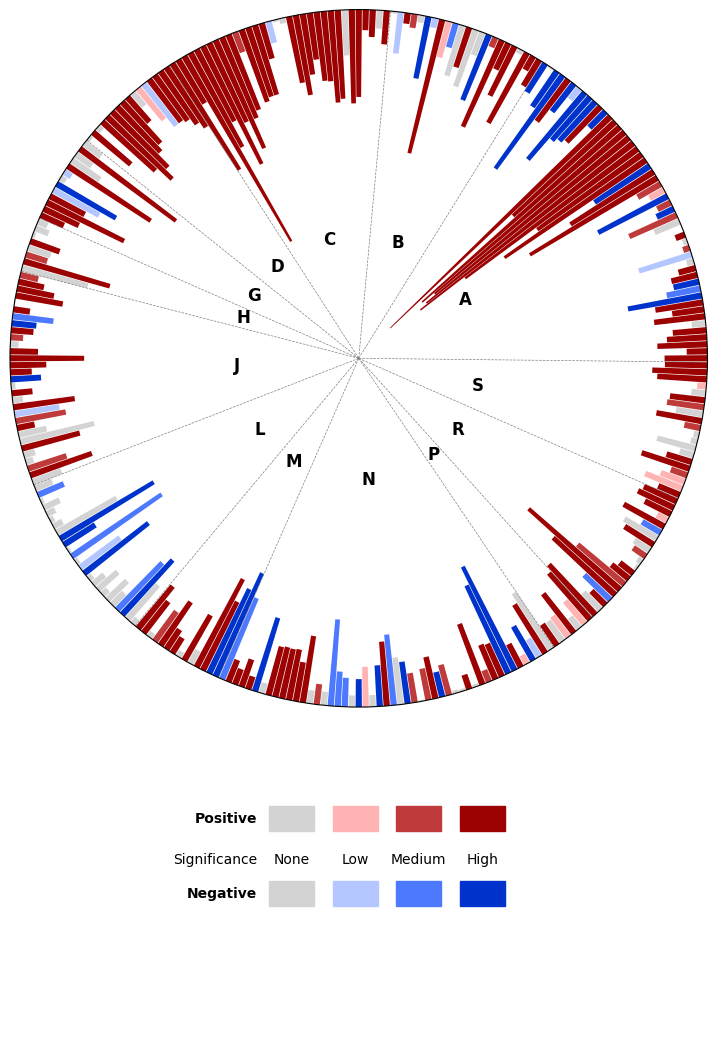

<Figure size 640x480 with 0 Axes>

In [154]:
fig = plot_circle_experimental(
    df_plot,
    outcome_col="outcome",
    log_rr_col="log_RR",
    q_value_col="q_value",
    group_col="group",
    group_label_radius=-1.6,
    show_separator_circle=False,
    separator_circle_margin=0.01,
    separator_circle_color="lightgrey",
    separator_circle_linewidth=.3,
    separator_circle_linestyle="--",
    max_bar_radius=-2.5,

)
plt.show()
plt.savefig("circle_plot_plus50.png", dpi=300)

## Custom Configuration
Modify parameters below to experiment:


# CVD Dataset


In [136]:
# Load CVD data
data_path_cvd = "../data/semaglutide/cvd/combined_estimates.txt"
df_raw_cvd = pd.read_csv(data_path_cvd)

print(f"CVD Dataset - Loaded {len(df_raw_cvd)} rows")
print(f"Unique outcomes: {df_raw_cvd['outcome'].nunique()}")
print(f"Runs: {df_raw_cvd['run_id'].nunique()}")


CVD Dataset - Loaded 4340 rows
Unique outcomes: 217
Runs: 4


In [137]:
# Filter to IPW and pool CVD data
df_method_cvd = df_raw_cvd[df_raw_cvd["method"] == "IPW"].copy()

df_pooled_cvd = compute_rd_pvalues(
    df_method_cvd,
    group_cols=("method", "outcome"),
    arm_pooling="inter_intra_variance",
    verbose=False,
)

# Calculate log RR
with np.errstate(divide="ignore", invalid="ignore"):
    df_pooled_cvd["RR"] = df_pooled_cvd["p1_hat"] / df_pooled_cvd["p0_hat"]
    df_pooled_cvd["log_RR"] = np.log(df_pooled_cvd["RR"])

# Adjust p-values
df_pooled_cvd["q_value"] = adjust_pvalues(df_pooled_cvd["p_value"].values, method="bh")

print(f"CVD - Pooled to {len(df_pooled_cvd)} outcomes")
print(f"CVD - Significant (q<0.05): {(df_pooled_cvd['q_value'] < 0.05).sum()}")


c:\Users\fjn197\PhD\projects\PHAIR\pipelines\trace_paper\trace\statistics.py:56: RuntimeWarning: invalid value encountered in subtract
  return (logit(hi) - logit(lo)) / (2 * z)


  Output p_value: #nan=9, #inf=0, finite=208/217
CVD - Pooled to 217 outcomes
CVD - Significant (q<0.05): 132


In [138]:
# Prepare CVD plotting dataframe
df_plot_cvd = df_pooled_cvd[["method", "outcome", "log_RR", "q_value", "p0_hat", "p1_hat"]].copy()
df_plot_cvd = df_plot_cvd.replace([np.inf, -np.inf], np.nan)
df_plot_cvd = df_plot_cvd.dropna(subset=["log_RR"]).copy()
df_plot_cvd["min_prevalence"] = df_plot_cvd[["p0_hat", "p1_hat"]].min(axis=1)
df_plot_cvd["group"] = df_plot_cvd["outcome"].astype(str).str[0]
df_plot_cvd = df_plot_cvd.sort_values("outcome").reset_index(drop=True)

print(f"CVD - Ready to plot {len(df_plot_cvd)} outcomes")
print(f"CVD - Groups: {', '.join(f'{g}({n})' for g, n in df_plot_cvd['group'].value_counts().sort_index().items())}")


CVD - Ready to plot 209 outcomes
CVD - Groups: A(38), B(16), C(28), D(5), G(10), H(3), J(22), L(6), M(12), N(38), P(2), R(14), S(11), V(4)


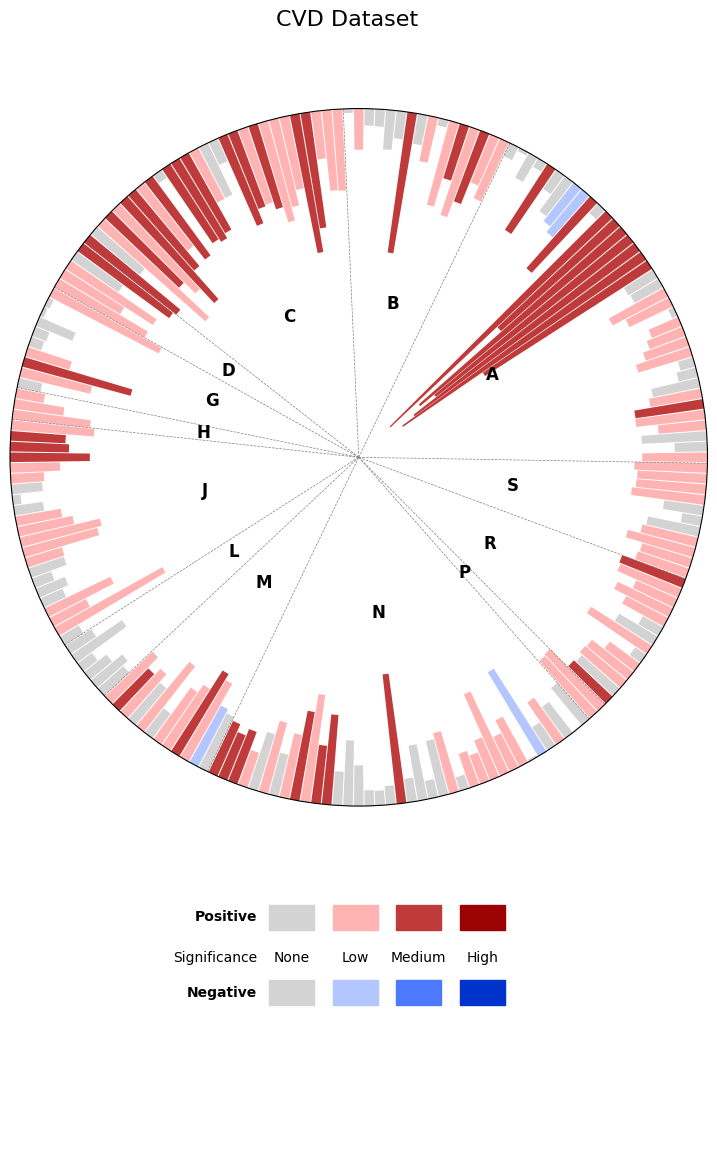

<Figure size 640x480 with 0 Axes>

In [157]:
# Plot CVD
df_plot_cvd = df_plot_cvd[df_plot_cvd["outcome"] != "A10BJ"]
df_plot_cvd = df_plot_cvd[df_plot_cvd["group"] != "V"]
fig = plot_circle_experimental(
    df_plot_cvd,
    outcome_col="outcome",
    log_rr_col="log_RR",
    q_value_col="q_value",
    group_col="group",
    group_label_radius=-1.2,
    show_separator_circle=False,
    separator_circle_margin=0.01,
    separator_circle_color="lightgrey",
    separator_circle_linewidth=.3,
    separator_circle_linestyle="--",
    max_bar_radius=-2.5,
)
plt.suptitle("CVD Dataset", fontsize=16, y=0.85)
plt.show()
plt.savefig("cvd_circle_plot.png", dpi=300)

# DIAB Dataset



In [142]:
# Load DIAB data
data_path_diab = "../data/semaglutide/diab/combined_estimates.txt"
df_raw_diab = pd.read_csv(data_path_diab)

print(f"DIAB Dataset - Loaded {len(df_raw_diab)} rows")
print(f"Unique outcomes: {df_raw_diab['outcome'].nunique()}")
print(f"Runs: {df_raw_diab['run_id'].nunique()}")


DIAB Dataset - Loaded 10800 rows
Unique outcomes: 216
Runs: 10


In [143]:
# Filter to IPW and pool DIAB data
df_method_diab = df_raw_diab[df_raw_diab["method"] == "IPW"].copy()

df_pooled_diab = compute_rd_pvalues(
    df_method_diab,
    group_cols=("method", "outcome"),
    arm_pooling="inter_intra_variance",
    verbose=False,
)

# Calculate log RR
with np.errstate(divide="ignore", invalid="ignore"):
    df_pooled_diab["RR"] = df_pooled_diab["p1_hat"] / df_pooled_diab["p0_hat"]
    df_pooled_diab["log_RR"] = np.log(df_pooled_diab["RR"])

# Adjust p-values
df_pooled_diab["q_value"] = adjust_pvalues(df_pooled_diab["p_value"].values, method="bh")

print(f"DIAB - Pooled to {len(df_pooled_diab)} outcomes")
print(f"DIAB - Significant (q<0.05): {(df_pooled_diab['q_value'] < 0.05).sum()}")


  Output p_value: #nan=0, #inf=0, finite=216/216
DIAB - Pooled to 216 outcomes
DIAB - Significant (q<0.05): 182


In [144]:
# Prepare DIAB plotting dataframe
df_plot_diab = df_pooled_diab[["method", "outcome", "log_RR", "q_value", "p0_hat", "p1_hat"]].copy()
df_plot_diab = df_plot_diab.replace([np.inf, -np.inf], np.nan)
df_plot_diab = df_plot_diab.dropna(subset=["log_RR"]).copy()
df_plot_diab["min_prevalence"] = df_plot_diab[["p0_hat", "p1_hat"]].min(axis=1)
df_plot_diab["group"] = df_plot_diab["outcome"].astype(str).str[0]
df_plot_diab = df_plot_diab.sort_values("outcome").reset_index(drop=True)

print(f"DIAB - Ready to plot {len(df_plot_diab)} outcomes")
print(f"DIAB - Groups: {', '.join(f'{g}({n})' for g, n in df_plot_diab['group'].value_counts().sort_index().items())}")


DIAB - Ready to plot 216 outcomes
DIAB - Groups: A(41), B(17), C(27), D(6), G(9), H(4), J(22), L(5), M(12), N(38), P(3), R(15), S(12), V(5)


In [146]:
df_plot_diab = df_plot_diab[df_plot_diab["outcome"] != "A10BJ"]
df_plot_diab = df_plot_diab[df_plot_diab["group"] != "V"]

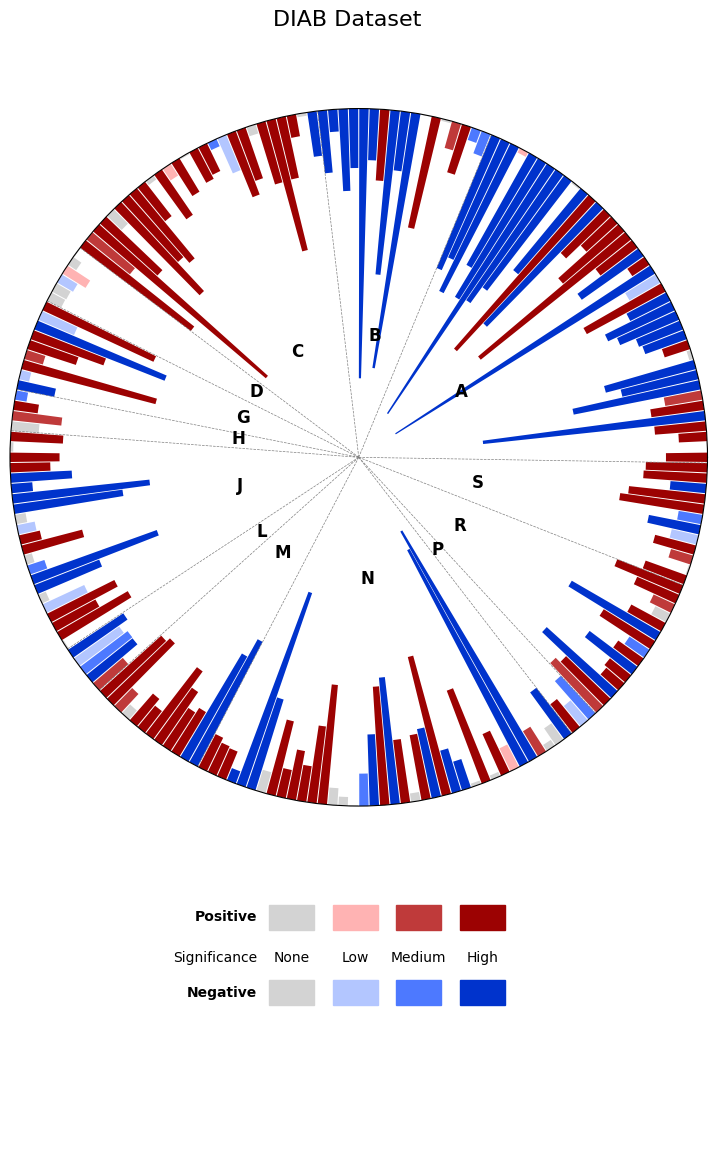

C:\Users\fjn197\AppData\Local\Temp\ipykernel_22584\601662090.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().set_visible(False)


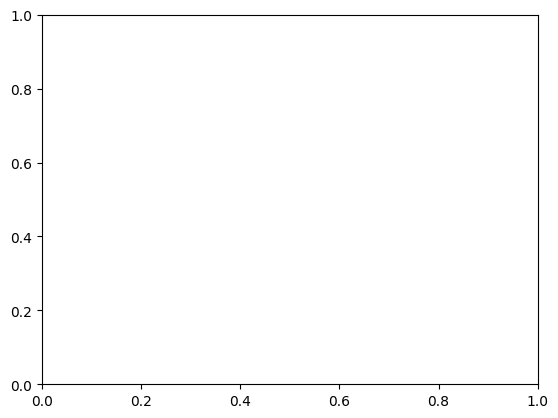

In [159]:
# Plot DIAB
fig = plot_circle_experimental(
    df_plot_diab,
    outcome_col="outcome",
    log_rr_col="log_RR",
    q_value_col="q_value",
    group_col="group",
    group_label_radius=-1.6,
    show_separator_circle=False,
    separator_circle_margin=0.01,
    separator_circle_color="lightgrey",
    separator_circle_linewidth=.3,
    separator_circle_linestyle="--",
    max_bar_radius=-2.5,
)
plt.suptitle("DIAB Dataset", fontsize=16, y=0.85)
plt.show()
plt.legend().set_visible(False)
plt.savefig("diab_circle_plot.png", dpi=300)
